In [1]:
# set up the python
import cosima_cookbook as cc
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40765,Workers: 28
Dashboard: /proxy/8787/status,Total threads: 28
Started: Just now,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:44081,Total threads: 1
Dashboard: /proxy/46197/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:44749,


2025-07-08 13:52:25,367 - distributed.nanny - WARNING - Restarting worker


In [3]:
session = cc.database.create_session()
db = '/g/data/x77/hm1221/CDW_changes/Jupyter_notebooks/RYF_perturbation.db'
session1 = cc.database.create_session(db)

In [4]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [5]:
# time period
start_time = '2152-01-01'
end_time = '2154-12-31'

In [6]:
#load T
temp_ctrl = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='temp', 
                          session=session, frequency='1 monthly').sel(time = slice(start_time, end_time))
temp_th = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585_th', variable='temp', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time, end_time))

[gadi-cpu-bdw-0603:586541:0:586541] Caught signal 11 (Segmentation fault: invalid permissions for mapped object at address 0x14b3d29b8730)
malloc(): unsorted double linked list corrupted
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWa

In [7]:
tendency_ctrl = xr.open_dataset('/scratch/x77/hm1221/nc_files/save_heat_budget/tendency_ctrl_mean_annual.nc')
pot_rho_1_ctrl = tendency_ctrl.pot_rho_1_ctrl
pot_rho_1_ctrl = pot_rho_1_ctrl.mean('time').load()
tendency_th = xr.open_dataset('/scratch/x77/hm1221/nc_files/save_heat_budget/tendency_th_mean_2yrs.nc')
pot_rho_1_th = tendency_th.pot_rho_1_th

In [8]:
shelf_mask = xr.open_dataarray('/scratch/x77/hm1221/nc_files/shelf_mask.nc')

st_ocean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/st_ocean.nc')

In [9]:
bound_up_mean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up_mean.nc')
bound_low_mean= xr.open_dataarray("/scratch/x77/hm1221/nc_files/bound_low_mean.nc")

In [10]:
## Get shelf mask
x_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/x_shelf.txt')
y_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/y_shelf.txt')

# Now, calculate the transect

In [11]:
def var_mean_5yr(var):
    var_mean_5yr = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time,end_time)).mean('time').load()

    return var_mean_5yr

In [12]:
temp_ctrl_mean = var_mean_5yr(temp_ctrl)
temp_th_mean = var_mean_5yr(temp_th)


In [13]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')
new_coord = new_coord.sel(yt_ocean = slice(-90,-40))

In [14]:
def Trans_lat_to_shelf(var,new_coord):
    var.load()
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean'})
    var_new_1 = var_new.sel(xt_ocean = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean')
    var_mean  = var_new.mean('xt_ocean').load()

    return [var_new,var_mean]

In [15]:
temp_ctrl_new,temp_ctrl_mean_new = Trans_lat_to_shelf(temp_ctrl_mean,new_coord)
temp_th_new,temp_th_mean_new = Trans_lat_to_shelf(temp_th_mean,new_coord)

  warnings.warn(

  warnings.warn(



In [16]:
new_coord_3d = new_coord.sel(yt_ocean = slice(-90,-44.96)).rename({'xt_ocean': 'xt_ocean_sub01', 'yt_ocean': 'yt_ocean_sub01'})
new_coord_2d = new_coord[0,:,:].sel(yt_ocean = slice(-90,-44.96))

In [17]:
new_coord_3d

<xarray.DataArray (st_ocean: 75, yt_ocean_sub01: 741, xt_ocean_sub01: 3600)> Size: 2GB
[200070000 values with dtype=float64]
Coordinates:
  * st_ocean        (st_ocean) float64 600B 0.5413 1.681 ... 5.511e+03 5.709e+03
  * yt_ocean_sub01  (yt_ocean_sub01) float64 6kB -81.11 -81.07 ... -45.04 -44.97
  * xt_ocean_sub01  (xt_ocean_sub01) float64 29kB -279.9 -279.8 ... 79.85 79.95

In [18]:
def Trans_lat_to_shelf(var,new_coord):
    var.load()
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean_sub01'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean_sub01'})
    var_new_1 = var_new.sel(xt_ocean_sub01 = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean_sub01 = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean_sub01')
    var_mean  = var_new.mean('xt_ocean_sub01').load()

    return [var_new,var_mean]

In [19]:
rho_th_new,rho_th_mean_new = Trans_lat_to_shelf(pot_rho_1_th,new_coord_3d)
rho_ctrl_new,rho_ctrl_mean_new = Trans_lat_to_shelf(pot_rho_1_ctrl,new_coord_3d)

  warnings.warn(

  warnings.warn(



# Fig in the manuscript

In [20]:
levs_dens = [32.0,32.3,32.5]

In [21]:
land_1 = xr.where(np.isnan(temp_ctrl_mean_new[1:,:].rename('land')),1, np.nan)

In [22]:
background_1 = xr.DataArray(
    data=np.ones_like(temp_ctrl_mean_new),
    coords=temp_ctrl_mean_new.coords,
    dims=temp_ctrl_mean_new.dims,
    name='ones_array'
)

Text(0, 0.5, 'temperature anomaly ($^{\\circ}$C)')

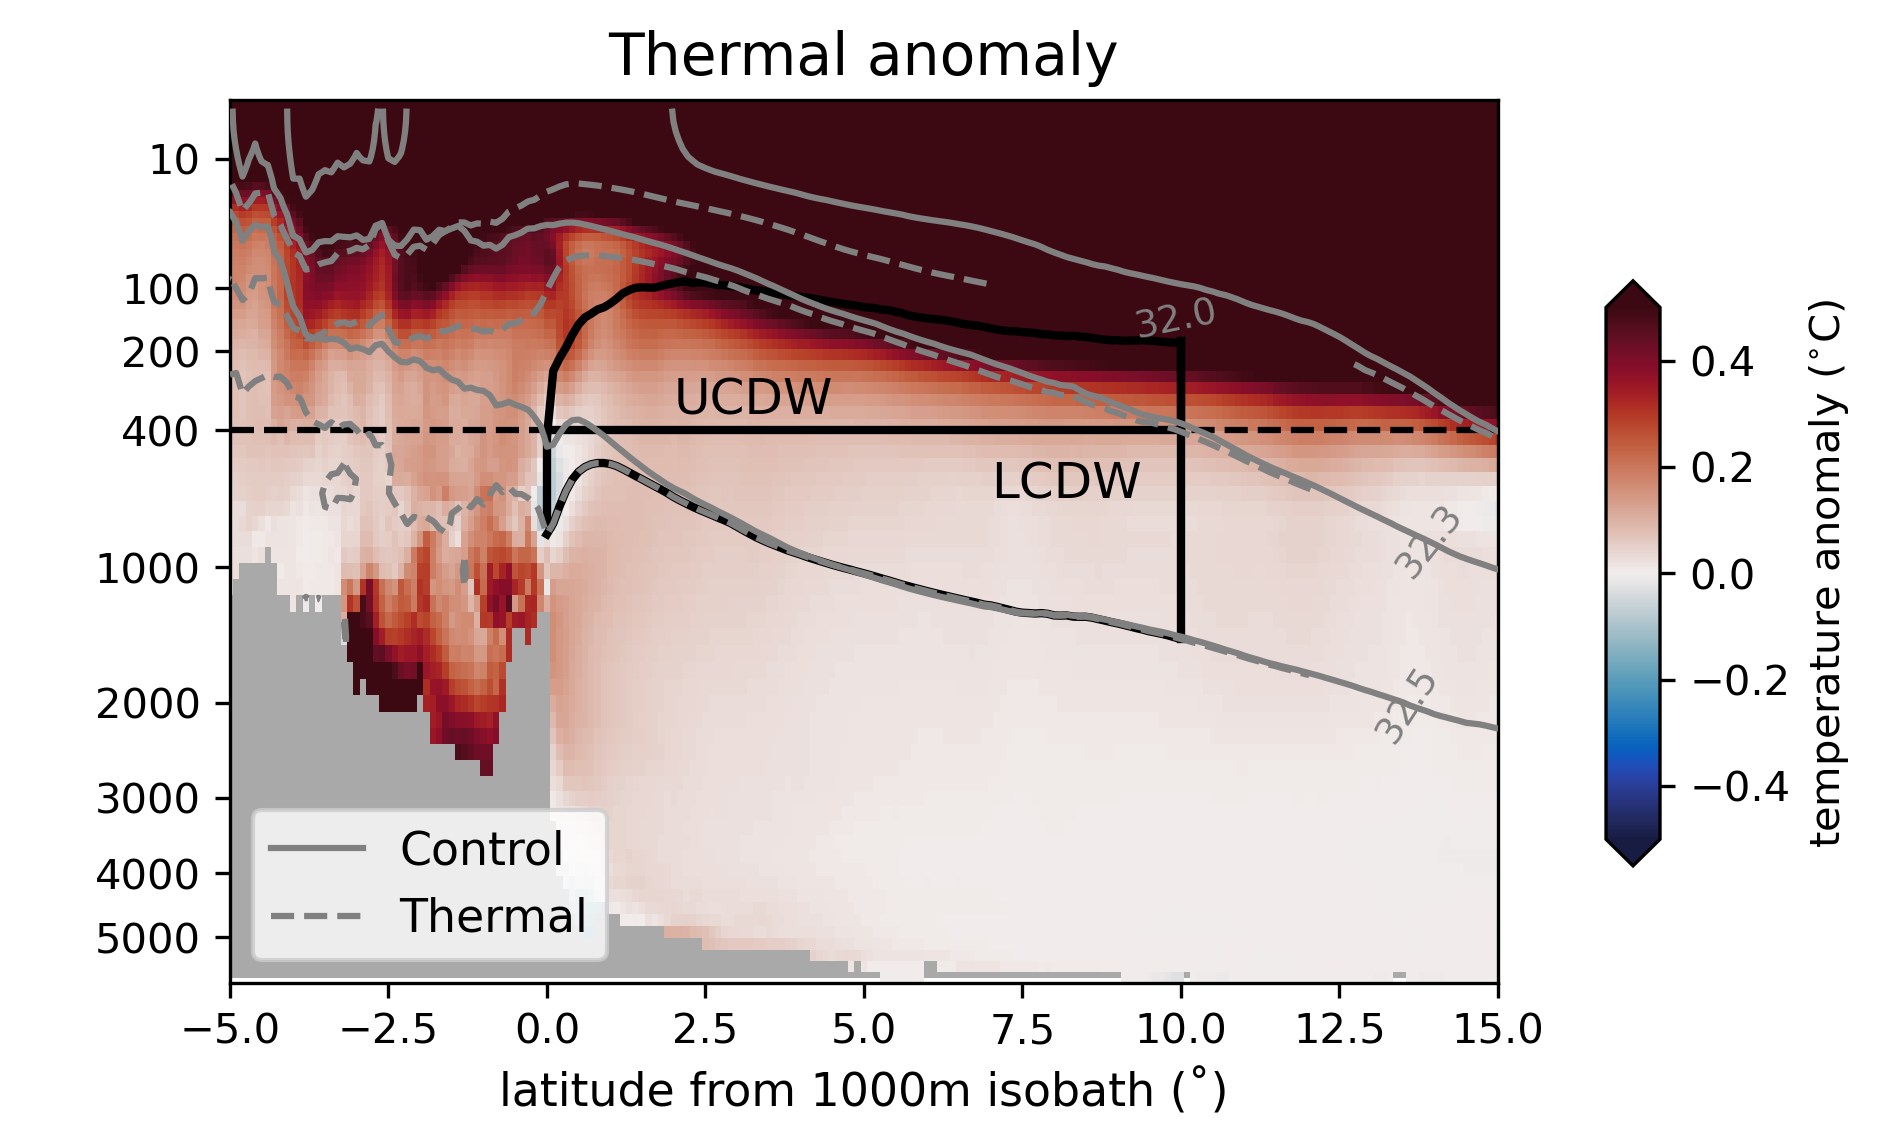

In [26]:
# For Figure S4
manual_positions = [
    (10, 100), 
    (12, 1000),
    (14,2000)
]
fig = plt.figure(figsize=(12,13),dpi = 300)

ax = plt.subplot(3,2,6)
plt.plot(0,0,color = 'grey',linestyle='-')
plt.plot(0,0,color = 'grey',linestyle='--')
plt.legend(['Control','Thermal'],
           fontsize = 11,loc = 'lower left',ncol=1)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = (temp_th_mean_new.sel(st_ocean = slice(1.,8000))-temp_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-0.5,vmax=0.5, cmap = cm.cm.balance,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean_sub01.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean_sub01.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('latitude from 1000m isobath (˚)', fontsize = 11)
plt.ylabel(' ', fontsize = 12)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_up_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_low_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low_mean[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
ax.set_title('Thermal anomaly', fontsize = 14)
# colorbar 
ax_cb2 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('temperature anomaly ($^{\circ}$C)', fontsize = 10)